<a href="https://colab.research.google.com/github/ENRIKO-18/D-DScience/blob/main/M3_P3_Practica_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/DCDPUAEM/DCDP/blob/main/03%20Machine%20Learning/notebooks/P3-Practica-Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⭕ Parte I: Clasificación

Este conjunto de datos, proporcionado por Avazu, contiene registros de publicidad en línea (como impresiones de anuncios y clicks) recolectados durante 11 días. El objetivo es predecir la probabilidad de que un usuario haga clic en un anuncio (CTR), una métrica crítica para optimizar campañas de sponsored search y real-time bidding. La práctica consiste en desarrollar un modelo de clasificación para este fin, utilizando características como el tipo de dispositivo, contexto de la página y datos anónimos del usuario.

La descripción completa de las features se proporciona a continuación:

| Nombre Columna      | Tipo (Ejemplo)           | Descripción                                                                 | ¿Relevante para Modelo? |
|---------------------|--------------------------|-----------------------------------------------------------------------------|-------------------------|
| `id`               | String (ej: "100000")    | Identificador único del registro (anuncio).                                 | ❌ No                   |
| **`click`**        | **Binaria (0/1)**        | **Variable target**: 0 = No hubo clic, 1 = Sí hubo clic.                    | ✅ **Sí**               |
| `year`, `month`, `hour`             | Int        | Año, mes y hora           | ✅ Sí  |
| `C1`               | Categórica anónima       | Variable categórica encriptada (sin contexto definido).                     | ✅ Sí                   |
| `banner_pos`       | Numérica/Categórica      | Posición del banner en la página (ej: 0, 1, 2...).                          | ✅ Sí                   |
| `site_id`          | Categórica (ej: "1fbe01")| ID del sitio web donde se muestra el anuncio.                               | ✅ Sí (alta cardinalidad) |
| `site_domain`      | Categórica (ej: "f38457")| Dominio del sitio web.                                                      | ⚠️ Tal vez (redundante con `site_id`) |
| `site_category`    | Categórica (ej: "28905b")| Categoría del sitio (ej: noticias, deportes...).                            | ✅ Sí                   |
| `app_id`           | Categórica (ej: "ecadf6")| ID de la aplicación (si el anuncio se muestra en una app móvil).             | ✅ Sí (alta cardinalidad) |
| `app_domain`       | Categórica (ej: "7801e8")| Dominio de la aplicación.                                                   | ⚠️ Tal vez (redundante con `app_id`) |
| `app_category`     | Categórica (ej: "07d7df")| Categoría de la aplicación (ej: juegos, redes sociales...).                 | ✅ Sí                   |
| `device_id`        | Categórica (ej: "a99f2a")| ID del dispositivo del usuario.                                             | ⚠️ Alta cardinalidad (¿agrupar?) |
| `device_ip`        | Categórica (ej: "d1b8b4")| Dirección IP del dispositivo.                                               | ❌ No (a menos que se agrupe por región) |
| `device_model`     | Categórica (ej: "8a4875")| Modelo del dispositivo (ej: iPhone X, Samsung Galaxy S10...).               | ✅ Sí                   |
| `device_type`      | Categórica (ej: 1, 2)    | Tipo de dispositivo (ej: 1 = móvil, 2 = tablet, etc.).                      | ✅ Sí                   |
| `device_conn_type` | Categórica (ej: 0, 2)    | Tipo de conexión (ej: 0 = WiFi, 2 = 4G...).                                 | ✅ Sí                   |
| `C14` - `C21`      | Categóricas anónimas     | Variables categóricas encriptadas (sin contexto definido).                   | ✅ Sí (evaluar importancia) |

Dataset: https://www.kaggle.com/competitions/avazu-ctr-prediction/data

In [36]:
import pandas as pd

url = 'https://github.com/DCDPUAEM/DCDP/raw/refs/heads/main/03%20Machine%20Learning/data/ctr_prediction.csv'

df = pd.read_csv(url)
df

,Unnamed: 0,click,C1,banner_pos,site_id,site_category,app_id,app_category,device_model,device_type,...,C15,C16,C17,C18,C19,C20,C21,year,month,day
0,0,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,44956a24,1,...,320,50,1722,0,35,-1,79,2014,10,21
1,1,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,711ee120,1,...,320,50,1722,0,35,100084,79,2014,10,21
2,2,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,8a4875bd,1,...,320,50,1722,0,35,100084,79,2014,10,21
3,3,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,6332421a,1,...,320,50,1722,0,35,100084,79,2014,10,21
4,4,0,1005,1,fe8cc448,0569f928,ecad2386,07d7df22,779d90c2,1,...,320,50,2161,0,35,-1,157,2014,10,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,0,1005,0,85f751fd,50e219e0,5e3f096f,0f2161f8,be74e6fe,1,...,320,50,2480,3,297,100111,61,2014,10,21
99996,99996,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,711ee120,1,...,320,50,1722,0,35,-1,79,2014,10,21
99997,99997,1,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,293291c1,1,...,320,50,1722,0,35,-1,79,2014,10,21
99998,99998,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,8a4875bd,1,...,320,50,1722,0,35,-1,79,2014,10,21


In [37]:
df.describe()

,Unnamed: 0,click,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,year,month,day
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.0,100000.0
mean,49999.500000,0.174900,1005.034410,0.19830,1.055730,0.199270,17682.145900,318.333960,56.818920,1964.034380,0.789350,131.734480,37874.227610,88.555670,2014.0,10.0,21.0
std,28867.657797,0.379883,1.088741,0.40264,0.583993,0.635268,3237.735265,11.931939,36.924104,394.962696,1.223761,244.076787,48546.274316,45.482841,0.0,0.0,0.0
min,0.000000,0.000000,1001.000000,0.00000,0.000000,0.000000,375.000000,120.000000,20.000000,112.000000,0.000000,33.000000,-1.000000,13.000000,2014.0,10.0,21.0
25%,24999.750000,0.000000,1005.000000,0.00000,1.000000,0.000000,15704.000000,320.000000,50.000000,1722.000000,0.000000,35.000000,-1.000000,61.000000,2014.0,10.0,21.0
50%,49999.500000,0.000000,1005.000000,0.00000,1.000000,0.000000,17654.000000,320.000000,50.000000,1993.000000,0.000000,35.000000,-1.000000,79.000000,2014.0,10.0,21.0
75%,74999.250000,0.000000,1005.000000,0.00000,1.000000,0.000000,20362.000000,320.000000,50.000000,2306.000000,2.000000,39.000000,100083.000000,156.000000,2014.0,10.0,21.0
max,99999.000000,1.000000,1010.000000,5.00000,5.000000,5.000000,21705.000000,728.000000,480.000000,2497.000000,3.000000,1835.000000,100248.000000,157.000000,2014.0,10.0,21.0


In [38]:
print(df.dtypes)

Unnamed: 0           int64
click                int64
C1                   int64
banner_pos           int64
site_id             object
site_category       object
app_id              object
app_category        object
device_model        object
device_type          int64
device_conn_type     int64
C14                  int64
C15                  int64
C16                  int64
C17                  int64
C18                  int64
C19                  int64
C20                  int64
C21                  int64
year                 int64
month                int64
day                  int64
dtype: object


## Instrucciones

0. Verifica si hay valores faltantes.
1. Extrae la variable target `click`. Verifica el balanceo de clases.
2. Quita las variables que consideres necesarias de acuerdo a la tabla anterior.
3. Forma la matriz de features `X`.
4. Convierte las variables categóricas en variables binarias mediante el one-hot encoding ([`get_dummies`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) de pandas). No olvides el hiperparámetro `drop_first=True` y `dtype=int`. Vas a obtener un dataframe con muchas columnas, es decir, ahora tenemos una muy alta dimensionalidad.
5. Divide en train/test
6. Verifica los rangos de las variables numéricas que tienes para la tarea de clasificación.
7. Realiza reducción de dimensionalidad con PCA con todas las componentes principales.
8. Escoge un número de componentes principales de manera que te quedes con el $\sim$80% de varianza.
9. Entrena un clasificador de tu elección en el conjunto de prueba. Evalua con la métrica F1-score
10. Reporta, además, la matriz de confusión.

0.  Verifica si hay valores faltantes.

In [39]:
df.isna().sum()

,0
Unnamed: 0,0
click,0
C1,0
banner_pos,0
site_id,0
site_category,0
app_id,0
app_category,0
device_model,0
device_type,0


 1. Extrae la variable target click. Verifica el balanceo de clases.

In [40]:
clicks=df['click'].value_counts()
clicks

,count
click,
0,82510
1,17490


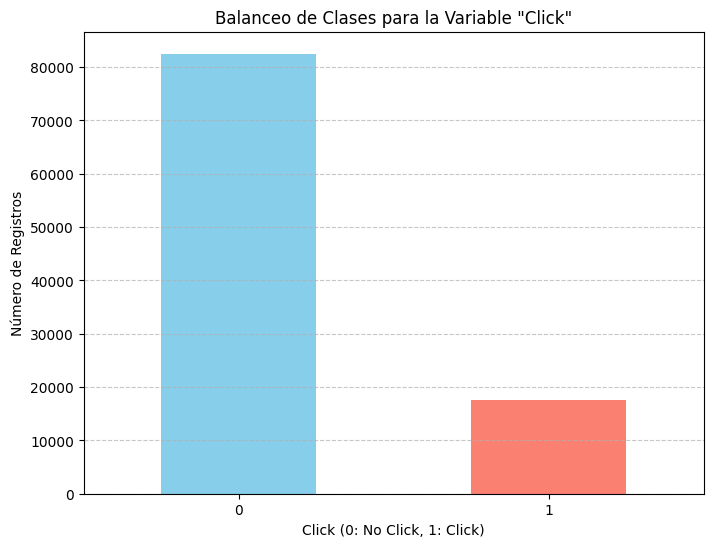

In [41]:
# Crear el gráfico de barras
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
clicks.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Balanceo de Clases para la Variable "Click"')
plt.xlabel('Click (0: No Click, 1: Click)')
plt.ylabel('Número de Registros')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

2. Quita las variables que consideres necesarias de acuerdo a la tabla anterior.

El dataframe de la URL ya no contiene las columnas: 'device_ip', 'site_domain', 'app_domain', 'device_id' por lo que no fue necesario borrarlas.

In [42]:
df2=df.copy()
df2 = df2.drop(columns=df.columns[0], axis=1)
#drop_cols = ['device_ip', 'site_domain', 'app_domain', 'device_id']
#df2=df2.drop(drop_cols, axis=1, inplace=True)
df2.head()

,click,C1,banner_pos,site_id,site_category,app_id,app_category,device_model,device_type,device_conn_type,...,C15,C16,C17,C18,C19,C20,C21,year,month,day
0,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,44956a24,1,2,...,320,50,1722,0,35,-1,79,2014,10,21
1,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,711ee120,1,0,...,320,50,1722,0,35,100084,79,2014,10,21
2,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,8a4875bd,1,0,...,320,50,1722,0,35,100084,79,2014,10,21
3,0,1005,0,1fbe01fe,28905ebd,ecad2386,07d7df22,6332421a,1,0,...,320,50,1722,0,35,100084,79,2014,10,21
4,0,1005,1,fe8cc448,0569f928,ecad2386,07d7df22,779d90c2,1,0,...,320,50,2161,0,35,-1,157,2014,10,21


3. Matriz de features X.

In [43]:
X=df2.drop('click', axis=1)
y=df2['click']
print(X.shape)
print(y.shape)

(100000, 20)
(100000,)


4. Convierte las variables categóricas en variables binarias mediante el one-hot encoding (get_dummies de pandas).

In [44]:
col_cat = X.select_dtypes(include='object').columns.tolist()
X2=pd.get_dummies(df2, columns=col_cat, drop_first=True, dtype=int)
X2.head()

,click,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,...,device_model_ff3242b8,device_model_ff503cfe,device_model_ff607a1a,device_model_ff717dd1,device_model_ff91ea03,device_model_ffb16766,device_model_ffcd1497,device_model_ffe3ae81,device_model_ffe69079,device_model_ffeafe15
0,0,1005,0,1,2,15706,320,50,1722,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1005,0,1,0,15704,320,50,1722,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1005,0,1,0,15704,320,50,1722,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1005,0,1,0,15706,320,50,1722,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1005,1,1,0,18993,320,50,2161,0,...,0,0,0,0,0,0,0,0,0,0


5. División Tain test

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=8)

6. Verifica los rangos de las variables numéricas que tienes para la tarea de clasificación

In [46]:
#print(X_train.describe())   # Se queda sin RAM.

7. Realiza reducción de dimensionalidad con PCA con todas las componentes principales.

In [ ]:
#Escalamiento previo a PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
# Ajustar el scaler solo en los datos de entrenamiento (fit, trasform) y prueba (trasform)
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

pca = PCA(n_components=500)
X_train_pca = pca.fit_transform(X_train_esc)    # Sólo entrenamos con el de entrenamiento
X_test_pca = pca.transform(X_test_esc)          # Sólo transformamos el de prueba

print(X_train_pca.shape)
print(X_test_pca.shape)

8. Escoge un número de componentes principales de manera que te quedes con el ∼80% de varianza.

In [ ]:
#Gráfica de varianza acumulda para selección de número de componentes principales

pca_variance_ratio = pca.explained_variance_ratio_
d = np.cumsum(pca_variance_ratio)

# Graficamos
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(range(pca_variance_ratio.shape[0]),d,
        ls='--',
        color='red',
        linewidth=2,
        )

plt.title('Varianza acumulada por dimensión')
plt.xlabel('Componente',fontsize=14)
plt.ylabel('Proporción',fontsize=14)
plt.grid(True)
ax.grid(which='major', color='gray', linestyle='-')
plt.show()

9. Entrena un clasificador de tu elección en el conjunto de prueba. Evalua con la métrica F1-score

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix

#Inicializar la clase
clf_svc = SVC(kernel='rbf', C=10, random_state=5, class_weight='balanced') # Kernel- función base radial. Aplico "balance"dado a desvalnace de "no clics" y "clics"

#Entrenamiento
clf_svc.fit(X_train_pca, y_train)

#Evaluación (accurcy)
print(f"Accuracy promedio de entrenamiento: {round(clf.score(X_train_pca, y_train),2)}")
print(f"Accuracy promedio de prueba: {round(clf.score(X_test_pca, y_test),2)}")

#F1-score
y_pred = clf_svc.predict(X_test_pca)
print(f"F1 Score: {f1_score(y_test,y_pred)}")

10. Matriz de confusión

In [ ]:
from sklearn.metrics import confusion_matrix
from seaborn import heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g')
plt.show()

# ⭕ Parte II: Segmentación y Recomendación

El dataset MovieLens 100K contiene información de 1682 películas, cada una representada por su título y 18 géneros cinematográficos (Action, Adventure, Drama, etc.), codificados como variables binarias. Estos datos, recolectados de calificaciones de 943 usuarios, permiten analizar las características intrínsecas de las películas independientemente de las preferencias de los usuarios.

El objetivo de esta práctica es realizar segmentación de películas mediante técnicas de clustering (como K-Means o clustering jerárquico) para identificar grupos naturales basados en sus géneros. Esto podría revelar patrones como *películas de acción con toques de sci-fi* o *dramas románticos con elementos musicales*, útiles para sistemas de recomendación o catálogos personalizados.

[Dataset completo en Kaggle](https://www.kaggle.com/datasets/prajitdatta/movielens-100k-dataset/data)

In [24]:
import os
import pandas as pd
import kagglehub
import numpy as np

path = kagglehub.dataset_download("prajitdatta/movielens-100k-dataset")
data_dir = os.path.join(path, 'ml-100k')
#path = '/root/.cache/kagglehub/datasets/prajitdatta/movielens-100k-dataset/versions/1/ml-100k'
fname = os.path.join(data_dir, 'u.item')

movies_df = pd.read_csv(fname, sep='|', encoding='latin-1', names=[
    'movie_id', 'title', 'release_date', 'video_release_date', 'IMDb_URL',
    'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
    'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
])

def get_year(date):
    try:
        return int(date.split('-')[-1])
    except:
        return np.nan

movies_df.drop(['video_release_date', 'unknown','IMDb_URL','movie_id'], axis=1, inplace=True)
movies_df['date'] = movies_df['release_date'].apply(get_year)
movies_df.drop('release_date', axis=1, inplace=True)
movies_df

,title,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,date
0,Toy Story (1995),0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1995.0
1,GoldenEye (1995),1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1995.0
2,Four Rooms (1995),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1995.0
3,Get Shorty (1995),1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1995.0
4,Copycat (1995),0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1995.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,Mat' i syn (1997),0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1998.0
1678,B. Monkey (1998),0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1998.0
1679,Sliding Doors (1998),0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1998.0
1680,You So Crazy (1994),0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1994.0


## Instrucciones

1. Verifica si hay variables faltantes.
2. Extraer las variables numéricas para formar la matriz de caracteristicas $X$.
3. Verifica los rangos de las variables, aplica re-escalamiento si lo consideras necesario.
4. Usa K-Means con algún valor $K$ de tu elección, haz clustering y mide el valor de silueta.
5. Encuentra el valor de codo y con ese valor, vuelve a hacer clustering y mide el valor de silueta.
6. Con el valor de $K$ que consideres mejor, extrae las etiquetas de los clusters y añadelas al dataframe `movies_df`.
7. Muestra un dataframe por cada cluster mostrando los títulos de las películas de cada cluster. ¿Es posible identificar, visualmente, qué define a cada cluster?


1. Verifica si hay variables faltantes.

In [6]:
print(movies_df.isna().sum())

title          0
Action         0
Adventure      0
Animation      0
Children's     0
Comedy         0
Crime          0
Documentary    0
Drama          0
Fantasy        0
Film-Noir      0
Horror         0
Musical        0
Mystery        0
Romance        0
Sci-Fi         0
Thriller       0
War            0
Western        0
date           1
dtype: int64


In [7]:
movies_df.dtypes

,0
title,object
Action,int64
Adventure,int64
Animation,int64
Children's,int64
Comedy,int64
Crime,int64
Documentary,int64
Drama,int64
Fantasy,int64


2. Extraer las variables numéricas para formar la matriz de caracteristicas X.

In [25]:
#Elimino la columna de "date" también dado que considero no aporta información relevante con la tarea

X =movies_df.drop(columns=['title','date'], axis=1)
X.head()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


3. Verifica los rangos de las variables, aplica re-escalamiento si lo consideras necesario.

In [26]:
X.describe()
#NO considero necesario reescalamiento dado que los datos son 0 ó 1.

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
count,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.00000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000
mean,0.149227,0.080262,0.024970,0.072533,0.300238,0.064804,0.029727,0.431034,0.01308,0.014269,0.054697,0.033294,0.036266,0.146849,0.060048,0.149227,0.042212,0.016052
std,0.356418,0.271779,0.156081,0.259445,0.458498,0.246253,0.169882,0.495368,0.11365,0.118632,0.227455,0.179456,0.187008,0.354061,0.237646,0.356418,0.201131,0.125714
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


4. Usa K-Means con algún valor K de tu elección, haz clustering y mide el valor de silueta.

In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [51]:
# Definir el número de clusters a buscar:
num_clusters = 10

modelo = KMeans(n_clusters=num_clusters)
modelo.fit(X)
y_clusters = modelo.predict(X)

print(silhouette_score(X, y_clusters))

0.40883169480597464


5. Encuentra el valor de codo y con ese valor, vuelve a hacer clustering y mide el valor de silueta

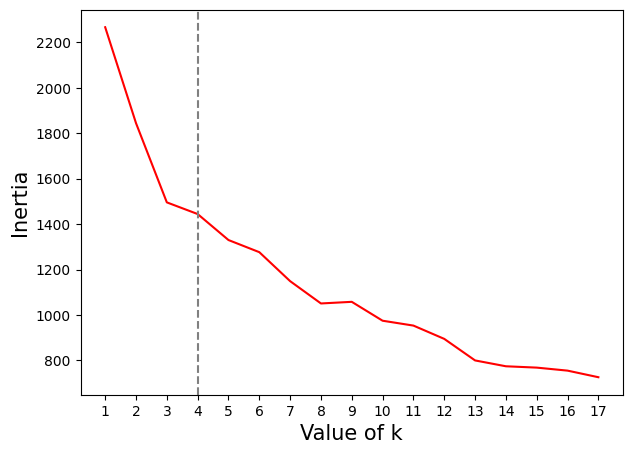

In [52]:
modelo.inertia_

max_num_clusters = 18

inertias = []
k_values = list(range(1,max_num_clusters))
for k in k_values:
    modelo = KMeans(n_clusters=k, n_init='auto')
    modelo.fit(X)
    inertias.append(modelo.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_values,inertias,color='red')
plt.axvline(x=4,linestyle='dashed',color='gray')
plt.ylabel("Inertia", fontsize=15)
plt.xlabel("Value of k", fontsize=15)
plt.xticks(k_values)
plt.show()

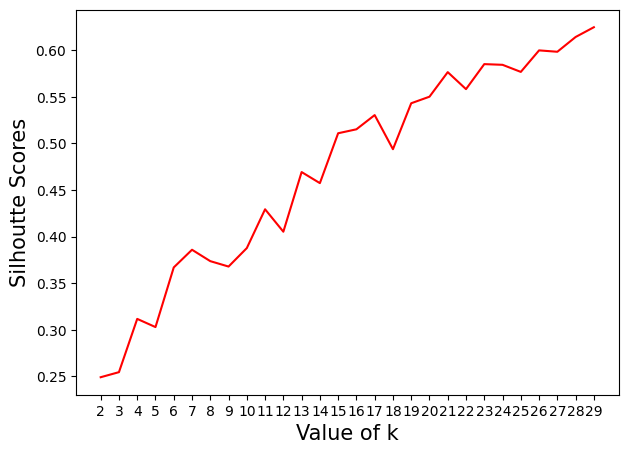

In [55]:
#Gráfico de Silhoutte

max_num_clusters = 30

best_num_clusters = 4

siluetas = []
k_values = list(range(2,max_num_clusters))
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init='auto').fit(X)
    labels = kmeans.labels_
    siluetas.append(silhouette_score(X, labels, metric='euclidean'))

plt.figure(figsize=(7,5))
plt.plot(k_values,siluetas,color='red')
# plt.axvline(x=best_num_clusters,linestyle='dashed',color='gray')
plt.xticks(k_values)
plt.ylabel("Silhoutte Scores", fontsize=15)
plt.xlabel("Value of k", fontsize=15)
plt.show()

NO es muy claro que valor de K usar dado que mientras mas Grande el Valor Silhoutte incrementa. AL mimo tiempo l valor "codo" indica un valor de k=4 como el adecuado.

In [57]:
# Definir el número de clusters a buscar:
num_clusters = 4

modelo = KMeans(n_clusters=num_clusters)
modelo.fit(X)
y_clusters = modelo.predict(X)

print(silhouette_score(X, y_clusters))

0.3465053768976458


6. Con el valor de K que consideres mejor, extrae las etiquetas de los clusters y añadelas al dataframe movies_df.

In [59]:
y_clusters=modelo.predict(X)
movies_df['cluster_label'] = y_clusters
movies_df.head(10)

,title,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,...,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,date,cluster_label
0,Toy Story (1995),0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1995.0,2
1,GoldenEye (1995),1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1995.0,0
2,Four Rooms (1995),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1995.0,0
3,Get Shorty (1995),1,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1995.0,1
4,Copycat (1995),0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,1995.0,1
5,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1995.0,1
6,Twelve Monkeys (1995),0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1995.0,1
7,Babe (1995),0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1995.0,1
8,Dead Man Walking (1995),0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1995.0,1
9,Richard III (1995),0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1996.0,1


7. Muestra un dataframe por cada cluster mostrando los títulos de las películas de cada cluster.

In [69]:
# Obtener la lista única de etiquetas de cluster
unique_clusters = sorted(movies_df['cluster_label'].unique())

# Iterar sobre cada cluster y mostrar los títulos de las películas
for cluster_id in unique_clusters:
    print(f"\n---Películas en Cluster {cluster_id}---")
    # Filtrar el DataFrame para obtener solo las películas de este cluster
    cluster_movies = movies_df[movies_df['cluster_label'] == cluster_id]
    # Mouestro solo la columna 'title'
    print(cluster_movies['title'].to_frame().reset_index(drop=True))


---Películas en Cluster 0---
                                           title
0                               GoldenEye (1995)
1                              Four Rooms (1995)
2                           Seven (Se7en) (1995)
3                     Usual Suspects, The (1995)
4                     From Dusk Till Dawn (1996)
..                                           ...
388                                  Hush (1998)
389                            Nightwatch (1997)
390  Land and Freedom (Tierra y libertad) (1995)
391                                Mirage (1995)
392                             B. Monkey (1998)

[393 rows x 1 columns]

---Películas en Cluster 1---
                                                 title
0                                    Get Shorty (1995)
1                                       Copycat (1995)
2    Shanghai Triad (Yao a yao yao dao waipo qiao) ...
3                                Twelve Monkeys (1995)
4                                          Babe (1995

**¿Es posible identificar, visualmente, qué define a cada cluster?**

Mas o menos. De ellas puedo intepretar:

* Cluster 0: se encuentran en su mayoría Trhiller, crimen, acción.
* Cluster 1: Mas diverso pero por lo que investigué destaca el Drama y la ciencia ficción.
* Cluster 2: Donde se encuentran títulos en su mayoría Infantiles y Familiares.
*Cluster 3: Con títulos de comedia y romance.

